# What Drives Counter-Strike 2 Skin Prices?

### PSTAT 100 Final Project, Spring 2026

**Kody Lai, Jeffrey Tat, Anthony Saenez, Stanley Lin, Noah Ruderman**

---
## Abstract

Counter-Strike 2 skins are cosmetic weapon finishes that trade for real money on third party marketplaces, with prices ranging from a few cents to over fifteen thousand dollars. In this project we ask what actually drives those prices. We pull 30 day sales summaries for every listed item from the Skinport API and clean the data down to 1,445 unique items across the four most popular weapons (AK-47, M4A1-S, M4A4, AWP), extracting wear condition, StatTrak status, Souvenir status, and skin name from each item's market listing name. After exploring the data, we fit a sequence of regression models. A baseline linear regression on raw prices explains almost none of the variance (R-squared of about 0.03) because the price distribution is extremely right skewed. Log transforming price and adding weapon category and sale volume brings R-squared up to 0.31, with condition the strongest attribute: each wear tier roughly doubles a skin's price. To go further we use Lasso regression, a regularization method beyond the scope of the course, which lets us safely include around 200 skin name dummy variables. The final model predicts held out prices with a root mean squared error around 220 dollars and shows that skin identity, not wear or StatTrak, is the dominant price driver. Finally, we use the model's residuals to flag potentially overvalued and undervalued skins, and a quick spot check on one flagged skin found its market price had already moved in the direction the model predicted.

---
# 1. Introduction

Counter-Strike 2 (CS2) is one of the most played games in the world, and a big part of its culture is weapon skins. Skins are purely cosmetic finishes for in game weapons, but they trade for real money on marketplaces like the Steam Community Market and third party sites such as Skinport. The market is surprisingly large, and individual skins can sell for anywhere from a few cents to five figures. An AWP Dragon Lore, for example, regularly sells for over ten thousand dollars.

What makes a skin expensive is only partly obvious. Every skin listing comes with a set of attributes: the weapon it goes on, the skin finish itself, a wear condition (from Factory New down to Battle-Scarred), whether it is a StatTrak version (which tracks kills), and whether it is a Souvenir drop from a tournament. Our project asks how much of a skin's price these measurable attributes can explain, and what is left over. Specifically:

1. How do condition, StatTrak, Souvenir status, and weapon category relate to a skin's average sale price?
2. How much of the price variation do these attributes explain on their own, compared to the identity of the skin itself?
3. Can a model that includes skin identity price skins well enough to flag items that look mispriced on the market?

To answer these questions we pulled a snapshot of 30 day sales data from the Skinport API, cleaned it down to the four most popular weapons, and fit a series of regression models of increasing complexity. Our main findings: attributes alone explain about 31% of the variation in log price, with each wear tier roughly doubling price. Once we add skin name dummy variables using Lasso regression (our beyond the scope of the course method), the model predicts held out prices with a root mean squared error of about 220 dollars, and the skin itself turns out to be the dominant driver of price. We finish by using the model to flag potentially mispriced skins.

The rest of this report is organized as follows. Section 2 lays out the methodology: the linear regression framework, the log transformation, how we compare models, and how Lasso regularization works. Section 3 covers the data, including where it came from, the full cleaning pipeline, and exploratory analysis. Section 4 presents the modeling results, from the failed raw price baseline through the final Lasso model and its application to finding market inefficiencies. Section 5 summarizes our conclusions and proposes further work, and Section 6 lists our references.

---
# 2. Methodology

## 2.1 Multiple linear regression and the log transform

Our core tool is multiple linear regression (MLR). For a response $y_i$ and predictors $x_{i1}, \dots, x_{ip}$, the model is

$$y_i = \beta_0 + \beta_1 x_{i1} + \cdots + \beta_p x_{ip} + \varepsilon_i,$$

and ordinary least squares (OLS) picks the coefficients that minimize the residual sum of squares. The usual assumptions are that the relationship is linear, the errors are independent with constant variance, and the errors are roughly normal.

Raw skin prices break these assumptions badly. Prices span four orders of magnitude and are extremely right skewed, so a handful of expensive skins dominate the fit and the residual variance is anything but constant. Our fix is to model $\log(\text{price})$ instead. The log compresses the right tail and also changes how we read coefficients: since the model is linear in log price, a one unit increase in $x_j$ multiplies the predicted price by $e^{\beta_j}$. So coefficients become percentage effects, which is a natural way to talk about prices.

## 2.2 Comparing OLS models

We fit several nested OLS models and compare them using adjusted $R^2$, AIC, and BIC:

$$\text{AIC} = 2k - 2\ln(\hat{L}), \qquad \text{BIC} = k\ln(n) - 2\ln(\hat{L}),$$

where $k$ is the number of parameters, $n$ the sample size, and $\hat{L}$ the maximized likelihood. All three reward fit but penalize extra parameters, so they protect against just stacking predictors. Lower AIC and BIC are better.

## 2.3 Train/test split and standardization

For the predictive models we split the data 75/25 into a training and test set. Models are fit (and any tuning is done) on the training set only, and we report error on the held out test set, which gives an honest estimate of out of sample performance.

Before fitting any penalized model we standardize every predictor to mean zero and variance one. This matters because the penalty treats all coefficients equally, so predictors on big scales (like volume) would otherwise be penalized differently than binary dummies. The scaler is fit on the training set only and then applied to the test set, so no information leaks from the test data.

## 2.4 Lasso regression (beyond the scope of the course)

Our extension method is the Lasso (Tibshirani, 1996), covered briefly in Lecture 15. The Lasso solves

$$\hat{\beta}^{\text{lasso}} = \arg\min_{\beta} \; \sum_{i=1}^{n}\Big(y_i - \beta_0 - \sum_{j=1}^{p} \beta_j x_{ij}\Big)^2 + \lambda \sum_{j=1}^{p} |\beta_j|.$$

The second term is an $L_1$ penalty on the coefficients. Unlike Ridge regression's squared penalty, the $L_1$ penalty can shrink coefficients all the way to exactly zero, so the Lasso does shrinkage and automatic variable selection at the same time. The tuning parameter $\lambda$ controls the tradeoff: $\lambda = 0$ gives back OLS, and very large $\lambda$ zeroes out everything. We choose $\lambda$ by 10-fold cross validation over a log spaced grid, using scikit-learn's `LassoCV`.

The Lasso is what makes our final model possible. Our data has around 200 distinct skin names with only about 4 observations per skin on average. An unpenalized OLS model with a dummy variable for every skin would technically fit, but the coefficient estimates would be very unstable at that sample size. The penalty keeps the estimates under control and drops the skin dummies that do not carry real signal.

## 2.5 Evaluation

We evaluate the predictive models on the test set using mean squared error (and its square root, RMSE, which is in dollars), along with the number of features each model keeps. For the final model we also check predicted versus actual plots and residual plots to make sure the fit is reasonable across the whole price range.

---
# 3. Data

## 3.1 Source and sample

Our data comes from [Skinport](https://skinport.com), a third party marketplace where players buy and sell CS2 skins for real money. Skinport publishes a free public API, and we pulled the sales history endpoint (`https://api.skinport.com/v1/sales/history?currency=USD`), which returns one record per unique item currently tracked on the site. Skinport itself prepares this data: it aggregates the individual sales of each item into summary statistics (minimum, maximum, average, and median price, plus the number of sales) over several time windows. We use the 30 day window. Everything downstream of that, including the cleaning, restructuring, and analysis, is our own work.

Each observation is one unique item, meaning a specific combination of weapon, skin finish, wear condition, and StatTrak/Souvenir status. The price columns are 30 day aggregates for that item, not individual transactions. After cleaning, our sample is 1,445 items covering the four most popular weapons in the game.

It is worth being upfront about what kind of sample this is. This is an observational snapshot of a single marketplace over a single 30 day window, not a random sample from the whole skin economy. Prices on Skinport can differ from the Steam Market or other sites, and a different month could look different. So our conclusions are about associations between item attributes and prices on Skinport during this window. We cannot make causal claims (we never intervene on anything), and we should be careful generalizing to other marketplaces or time periods.

## 3.2 Data cleaning and restructuring

The raw API response needs a fair amount of work before it is usable. In this section we walk through the pipeline: selecting columns, handling missingness, restructuring the listing names into separate variables, and correcting types. We start by loading the saved JSON response and converting it to a CSV for easier handling.

In [69]:
# Libraries
import numpy as np
import pandas as pd
import missingno as msno
import matplotlib.pyplot as plt
import seaborn as sns

# Figure formatting
sns.set_style("whitegrid")
sns.set_palette("Set2")

In [70]:
# JSON taken from saving https://api.skinport.com/v1/sales/history?currency=USD

df = pd.read_json('data/skinport_items.json')
df.to_csv('data/skinport_items.csv', index=False)

# Identify the columns we want to keep
print(df.head())
print(df.columns) 




                             market_hash_name version currency  \
0  Sticker Slab | BIG (Gold) | Stockholm 2021     NaN      USD   
1  Sticker Slab | Kvik (Foil) | Katowice 2019     NaN      USD   
2         Sticker Slab | B1ad3 | Cologne 2015     NaN      USD   
3                   Sticker Slab | Pocket BBQ     NaN      USD   
4          Sticker Slab | oSee | Antwerp 2022     NaN      USD   

                                           item_page  \
0  https://skinport.com/item/sticker-slab-big-gol...   
1  https://skinport.com/item/sticker-slab-kvik-fo...   
2  https://skinport.com/item/sticker-slab-b1ad3-c...   
3  https://skinport.com/item/sticker-slab-pocket-bbq   
4  https://skinport.com/item/sticker-slab-osee-an...   

                                         market_page  \
0  https://skinport.com/market?item=BIG%20(Gold)%...   
1  https://skinport.com/market?item=Kvik%20(Foil)...   
2  https://skinport.com/market?item=B1ad3%20%7C%2...   
3  https://skinport.com/market?item=Pocket

### Selecting columns

The JSON response gives us 9 columns: `'market_hash_name', 'version', 'currency', 'item_page', 'market_page', 'last_24_hours', 'last_7_days', 'last_30_days', 'last_90_days'`. From an initial glance, `'item_page'` and `'market_page'` are just links to each item's store page, and since we are interested in quantifiable data we can drop those two. We are also only interested in the past month of data, so we drop the other time windows and keep `'last_30_days'`.

In [71]:
#Creating a temporary cleaned data frame with only columns we want to keep for analysis
df_cleaned_temp = df.drop(columns=[
    "item_page",
    "market_page",
    "last_24_hours",
    "last_7_days",
    "last_90_days"
])

print(df_cleaned_temp.shape)
df_cleaned_temp.head()

(33855, 4)


,market_hash_name,version,currency,last_30_days
0,Sticker Slab | BIG (Gold) | Stockholm 2021,NaN,USD,"{'min': None, 'max': None, 'avg': None, 'media..."
1,Sticker Slab | Kvik (Foil) | Katowice 2019,NaN,USD,"{'min': None, 'max': None, 'avg': None, 'media..."
2,Sticker Slab | B1ad3 | Cologne 2015,NaN,USD,"{'min': None, 'max': None, 'avg': None, 'media..."
3,Sticker Slab | Pocket BBQ,NaN,USD,"{'min': None, 'max': None, 'avg': None, 'media..."
4,Sticker Slab | oSee | Antwerp 2022,NaN,USD,"{'min': None, 'max': None, 'avg': None, 'media..."


Notice that `'last_30_days'` is a dictionary containing `'min'`, `'max'`, `'avg'`, `'median'`, and `'volume'`. We can extract these out into their own columns.

In [72]:
last_30_days = pd.json_normalize(df['last_30_days']) # expand the dictionary of last_30_days into a temporary data frame

df_cleaned_temp = df_cleaned_temp.join(last_30_days)
df_cleaned_temp = df_cleaned_temp.drop(columns='last_30_days')

df_cleaned_temp.head()

,market_hash_name,version,currency,min,max,avg,median,volume
0,Sticker Slab | BIG (Gold) | Stockholm 2021,NaN,USD,NaN,NaN,NaN,NaN,0
1,Sticker Slab | Kvik (Foil) | Katowice 2019,NaN,USD,NaN,NaN,NaN,NaN,0
2,Sticker Slab | B1ad3 | Cologne 2015,NaN,USD,NaN,NaN,NaN,NaN,0
3,Sticker Slab | Pocket BBQ,NaN,USD,NaN,NaN,NaN,NaN,0
4,Sticker Slab | oSee | Antwerp 2022,NaN,USD,NaN,NaN,NaN,NaN,0


### Missingness

Next we check for missing data, both as a table and visually with `missingno`.

                  Missing Values  Percent Missing
market_hash_name               0         0.000000
version                    32889        97.146655
currency                       0         0.000000
min                        16205        47.865899
max                        16205        47.865899
avg                        16205        47.865899
median                     16205        47.865899
volume                         0         0.000000


<Axes: >

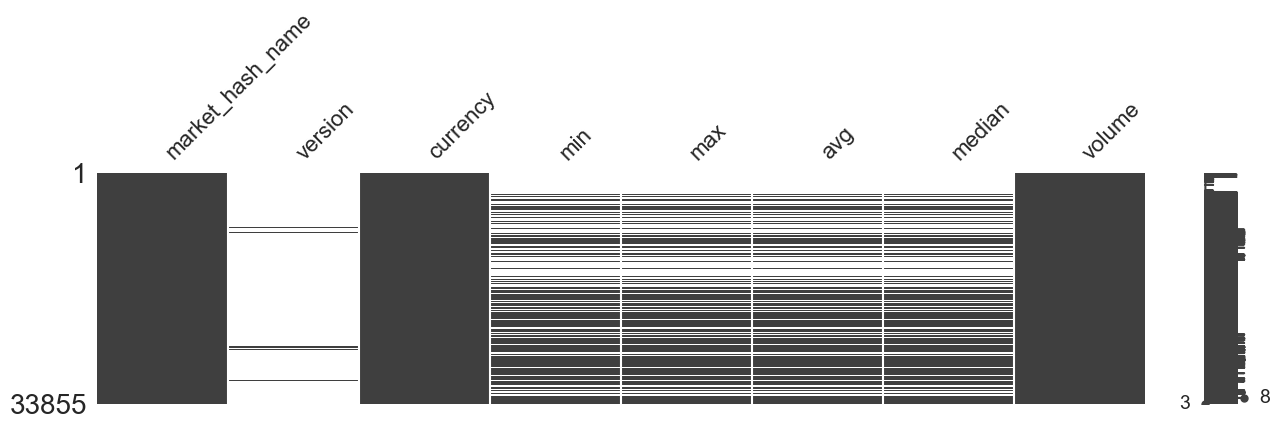

In [73]:
missing_table = pd.DataFrame({
        'Missing Values': df_cleaned_temp.isna().sum(), 
        'Percent Missing': df_cleaned_temp.isna().mean() * 100
    })

print(missing_table)


# We can visualize the missing data with missingno
msno.matrix(df_cleaned_temp, figsize=(15, 3)) 

All of the missingness comes from the same entries: items with no recorded sales in the window have every statistic missing at once. Since these rows carry no price information, we remove rows where every statistic is missing.

In [74]:
# Remove rows where every statistic is missing
df_cleaned_temp = df_cleaned_temp.dropna(subset=["min", "max", "avg", "median"], how="all") # version is not dropped as None *is* a valid version rather than representing null

new_missing_table = pd.DataFrame({
        'Missing Values': df_cleaned_temp.isna().sum(), 
        'Percent Missing': df_cleaned_temp.isna().mean() * 100
    })

print(new_missing_table)
print(df_cleaned_temp.shape) # removed exactly 16205 entires, as expected
df_cleaned_temp.head()

                  Missing Values  Percent Missing
market_hash_name               0         0.000000
version                    17251        97.739377
currency                       0         0.000000
min                            0         0.000000
max                            0         0.000000
avg                            0         0.000000
median                         0         0.000000
volume                         0         0.000000
(17650, 8)


,market_hash_name,version,currency,min,max,avg,median,volume
210,Souvenir AK-47 | Steel Delta (Field-Tested),NaN,USD,4.06,8.61,5.35,4.87,7
332,Souvenir XM1014 | Hieroglyph (Factory New),NaN,USD,0.56,1.20,0.99,1.04,6
343,Souvenir MAG-7 | Copper Coated (Field-Tested),NaN,USD,0.35,1.16,0.59,0.44,4
580,Souvenir P90 | ScaraB Rush (Well-Worn),NaN,USD,4.92,4.92,4.92,4.92,1
2795,AK-47 | Black Laminate (Well-Worn),NaN,USD,58.03,58.03,58.03,58.03,1


### Restructuring and relabeling: extracting item attributes

The column `'market_hash_name'` packs a lot of information about each skin into one string, including `Souvenir` status, `StatTrak` status, the skin name, and the item condition. We can break it apart into separate categorical variables.

We also want to focus on the most commonly used weapons in the game, since those are the most actively traded. We filter to the `AK-47`, `M4A1-S`, `M4A4`, and `AWP`.

In [75]:
# create new columns souvenir and stat_trak

df_cleaned_temp["souvenir"] = df_cleaned_temp["market_hash_name"].str.contains("Souvenir")
df_cleaned_temp["stat_trak"] = df_cleaned_temp["market_hash_name"].str.contains("StatTrak")

#filtering 4 most popular guns for analysis

temp_df = df_cleaned_temp[df_cleaned_temp["market_hash_name"].str.contains("AK-47|M4A1-S|M4A4|AWP")]

temp_df.head()
df_cleaned = temp_df
df_cleaned.head()

,market_hash_name,version,currency,min,max,avg,median,volume,souvenir,stat_trak
210,Souvenir AK-47 | Steel Delta (Field-Tested),NaN,USD,4.06,8.61,5.35,4.87,7,True,False
2795,AK-47 | Black Laminate (Well-Worn),NaN,USD,58.03,58.03,58.03,58.03,1,False,False
2813,AK-47 | Aquamarine Revenge (Battle-Scarred),NaN,USD,27.33,35.98,32.02,31.67,7,False,False
2814,AK-47 | Fire Serpent (Factory New),NaN,USD,2485.40,2625.52,2555.46,2555.46,2,False,False
2908,AK-47 | Predator (Battle-Scarred),NaN,USD,9.23,9.68,9.46,9.45,2,False,False


We can now break apart `'market_hash_name'` into separate variables (`weapon`, `skin_name`, `condition`).

In [76]:
# seperate market hash name into different variables
df_cleaned[['weapon', 'skin_name', 'condition']] = df_cleaned['market_hash_name'].str.extract(r'(.+?)\s*\|\s*(.+?)\s*\((.+?)\)', expand=True)

# embellishments (souvenir, stattrak) are unecessary to remove because we will filter weapon types through .contains() anyways

df_cleaned=df_cleaned.drop(columns='market_hash_name')
df_cleaned.head()

,version,currency,min,max,avg,median,volume,souvenir,stat_trak,weapon,skin_name,condition
210,NaN,USD,4.06,8.61,5.35,4.87,7,True,False,Souvenir AK-47,Steel Delta,Field-Tested
2795,NaN,USD,58.03,58.03,58.03,58.03,1,False,False,AK-47,Black Laminate,Well-Worn
2813,NaN,USD,27.33,35.98,32.02,31.67,7,False,False,AK-47,Aquamarine Revenge,Battle-Scarred
2814,NaN,USD,2485.40,2625.52,2555.46,2555.46,2,False,False,AK-47,Fire Serpent,Factory New
2908,NaN,USD,9.23,9.68,9.46,9.45,2,False,False,AK-47,Predator,Battle-Scarred


Reorder columns for better readability.

In [77]:
# Remove souvenir / StatTrak from weapon names since we already have tuples categories
df_cleaned['weapon'] = df_cleaned['weapon'].str.replace(
    r"(Souvenir\s+|StatTrak™?\s+)",
    "",
    regex=True
).str.strip()

#Reordering columns for better readability
first_cols = ["weapon", "skin_name", "condition"]
other_cols = [col for col in df_cleaned.columns if col not in first_cols]

df_cleaned = df_cleaned[first_cols + other_cols]

df_cleaned.head()

,weapon,skin_name,condition,version,currency,min,max,avg,median,volume,souvenir,stat_trak
210,AK-47,Steel Delta,Field-Tested,NaN,USD,4.06,8.61,5.35,4.87,7,True,False
2795,AK-47,Black Laminate,Well-Worn,NaN,USD,58.03,58.03,58.03,58.03,1,False,False
2813,AK-47,Aquamarine Revenge,Battle-Scarred,NaN,USD,27.33,35.98,32.02,31.67,7,False,False
2814,AK-47,Fire Serpent,Factory New,NaN,USD,2485.40,2625.52,2555.46,2555.46,2,False,False
2908,AK-47,Predator,Battle-Scarred,NaN,USD,9.23,9.68,9.46,9.45,2,False,False


### Type correction: encoding condition and the binary flags

For regression we want numeric variables. In CS2, a weapon's condition affects its price, so we assign each of the five wear tiers a numeric code from 0 (Battle-Scarred) to 4 (Factory New). Since we are converting things to numbers anyway, we also convert the boolean `'souvenir'` and `'stat_trak'` columns into 0/1 binary values.

In [78]:
# Convert souvenir and stat_trak boolean status to binary for regression purposes
df_cleaned["souvenir"] = df_cleaned["souvenir"].astype(int)
df_cleaned["stat_trak"] = df_cleaned["stat_trak"].astype(int)


# map values to condition for linear regression purposes
condition_codes = {
    "Factory New": 4, 
    "Minimal Wear": 3, 
    "Field-Tested": 2,
    "Well-Worn": 1, 
    "Battle-Scarred": 0,
}

# recode age categories
df_cleaned_enc = df_cleaned.replace({'condition': condition_codes})

df = df_cleaned_enc

df.head()

,weapon,skin_name,condition,version,currency,min,max,avg,median,volume,souvenir,stat_trak
210,AK-47,Steel Delta,2,NaN,USD,4.06,8.61,5.35,4.87,7,1,0
2795,AK-47,Black Laminate,1,NaN,USD,58.03,58.03,58.03,58.03,1,0,0
2813,AK-47,Aquamarine Revenge,0,NaN,USD,27.33,35.98,32.02,31.67,7,0,0
2814,AK-47,Fire Serpent,4,NaN,USD,2485.40,2625.52,2555.46,2555.46,2,0,0
2908,AK-47,Predator,0,NaN,USD,9.23,9.68,9.46,9.45,2,0,0


Finally, we drop rows whose `'condition'` isn't one of our five wear tiers. These are items whose parenthetical wasn't a wear tier, usually due to special characters (e.g. `'M4A4 | 龍王 (Dragon King)'`), plus stickers/graffiti and unparsed rows that slipped through the weapon filter.

In [79]:
print("Before:", df.shape)

# keep only rows where condition is one of our 5 wear tiers (0-4)
df = df[df["condition"].isin([0, 1, 2, 3, 4])]
df["condition"] = df["condition"].astype(int)

print("After: ", df.shape)
print(df["weapon"].value_counts())   # sanity check: should be just the 4 weapons
df.head()


Before: (1469, 12)
After:  (1445, 12)
weapon
AK-47     455
AWP       339
M4A4      337
M4A1-S    314
Name: count, dtype: int64


,weapon,skin_name,condition,version,currency,min,max,avg,median,volume,souvenir,stat_trak
210,AK-47,Steel Delta,2,NaN,USD,4.06,8.61,5.35,4.87,7,1,0
2795,AK-47,Black Laminate,1,NaN,USD,58.03,58.03,58.03,58.03,1,0,0
2813,AK-47,Aquamarine Revenge,0,NaN,USD,27.33,35.98,32.02,31.67,7,0,0
2814,AK-47,Fire Serpent,4,NaN,USD,2485.40,2625.52,2555.46,2555.46,2,0,0
2908,AK-47,Predator,0,NaN,USD,9.23,9.68,9.46,9.45,2,0,0


Now that we have finished cleaning the data, we write it out to a csv file (`skinport_items_cleaned(1).csv`) for the rest of the analysis to use.

In [80]:
# write to csv for others to use

df.to_csv('data/skinport_items_cleaned(1).csv', index=False)

## 3.3 Exploratory data analysis

With the data cleaned, we can explore it. To make this section self contained, we reload the cleaned csv from disk. We also check for duplicated rows here: the API returns one record per unique item, so we expect zero, but it is worth confirming since duplicate rows would silently double count items in everything that follows.

In [2]:
# Reload the cleaned dataset so the analysis sections can run on their own
df = pd.read_csv('data/skinport_items_cleaned(1).csv')

# Drop two leftover columns with no analytical value if they are still present
# (currency is identical for every row and version is ~98% missing)
df = df.drop(columns=['version', 'currency'], errors='ignore')

# Check for duplicated rows: the API returns one row per unique item, so we expect 0
print("Duplicated rows:", df.duplicated().sum())
print("Shape:", df.shape)

Duplicated rows: 0
Shape: (1445, 10)


For a quick initial look, we count how many items we have for each weapon.

In [3]:
df['weapon'].value_counts().to_frame()

,count
weapon,
AK-47,455
AWP,339
M4A4,337
M4A1-S,314


### Histograms

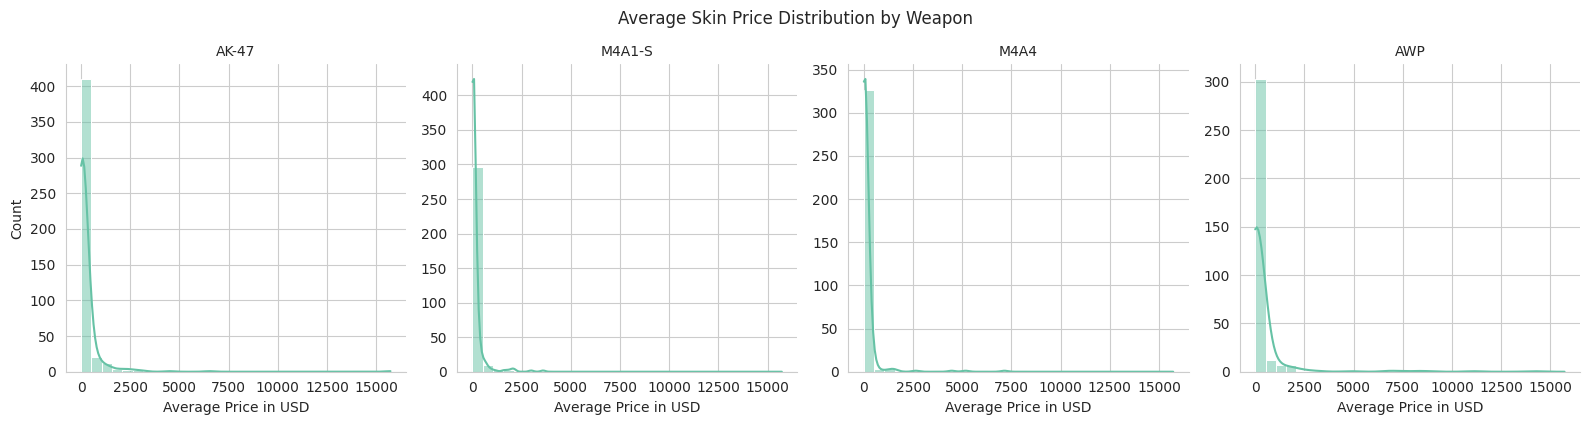

weapon
AK-47     12.04
AWP        6.89
M4A1-S     5.77
M4A4       8.93
Name: avg, dtype: float64

In [4]:
# Keep only the 4 weapon categories
weapon_order = ["AK-47", "M4A1-S", "M4A4", "AWP"]
df_weapons = df[df["weapon"].isin(weapon_order)].copy()

# Make sure avg is numeric
df_weapons["avg"] = pd.to_numeric(df_weapons["avg"], errors="coerce")

# Remove missing avg values
df_weapons = df_weapons.dropna(subset=["avg"])

# Raw histogram by weapon
g = sns.displot(
    data=df_weapons,
    x="avg",
    col="weapon",
    col_order=weapon_order,
    bins=30,
    kde=True,
    height=4,
    aspect=1,
    facet_kws={"sharex": True, "sharey": False}
)

g.set_axis_labels("Average Price in USD", "Count")
g.set_titles("{col_name}")
g.fig.suptitle("Average Skin Price Distribution by Weapon", y=1.05)

plt.show()
df_weapons.groupby("weapon")["avg"].skew().round(2)

The raw histograms show that average skin prices are highly right-skewed, with the majority of skins concentrated around lower price points. This makes sense, as Counter-Strike's skin market is notoriously known for a few very expensive skins, like the AWP Dragon Lore being priced around $11,000. For visualization purposes, we can apply a log transformation to `'avg'`.

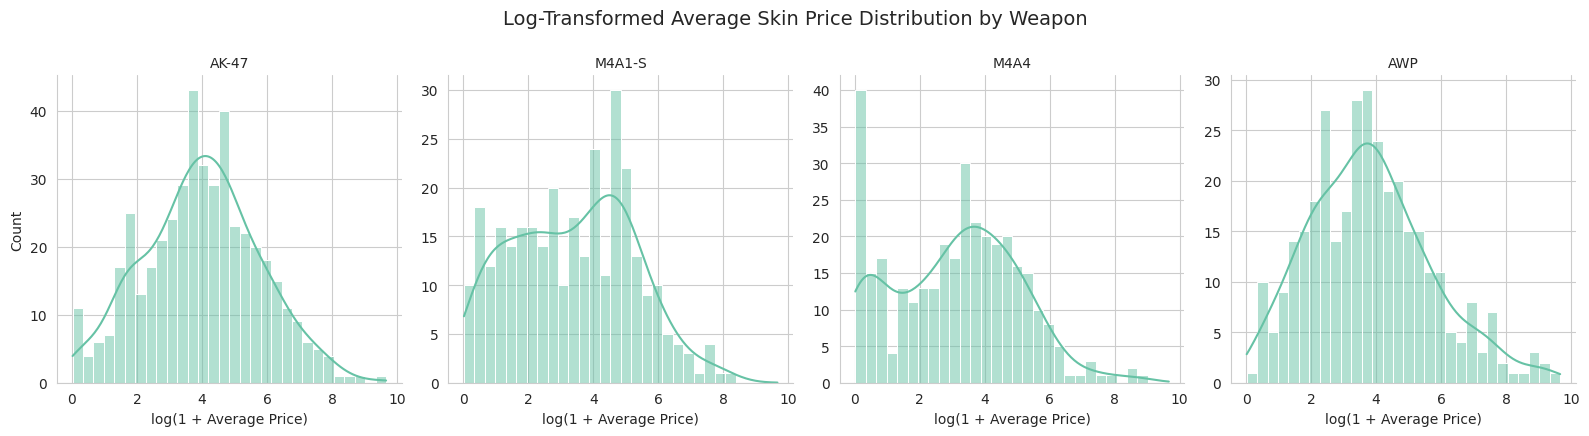

In [5]:
# Create log-transformed avg column
df_weapons["log_avg"] = np.log1p(df_weapons["avg"])

# log_avg histogram
g = sns.displot(
    data=df_weapons,
    x="log_avg",
    col="weapon",
    col_order=weapon_order,
    bins=30,
    kde=True,
    height=4,
    aspect=1,
    facet_kws={"sharex": True, "sharey": False}
)

g.set_axis_labels("log(1 + Average Price)", "Count")
g.set_titles("{col_name}")

g.fig.suptitle(
    "Log-Transformed Average Skin Price Distribution by Weapon",
    y=1.08,
    fontsize=14
)

plt.show()

---

We can see that there is kind of an interesting pattern. For context, the game is separated into two teams; Terrorist (T) and Counter-Terrorist (CT), with the AK-47, M4A1-S, M4A4, and the AWP being "primary" weapons. There is nuance, in the fact that there are other weapons within the game, but for the majority of players, these weapons define the game.

What is interesting is the price distributions for the M4A1-S and M4A4. The M4A1-S and M4A4 are CT sided weapons only, where the restriction is that they do not have the ability to one shot an opponent. Contrary to the AK47, which is the only primary weapon for the T side. The AWP is its own separate "rifle" in the manner that it is a sniper rifle, but can be equipped on both sides.

The distributions for the average AK-47 and AWP prices follow an approximate bell curve. In contrast, the M4A1-S and the M4A4 show more tendencies to sell at lower-price points.

These trends could probably be explained by the fact that the AK-47 being the only "primary" weapon for the T side. While the M4A1-S and M4A4 are two options CT players can choose from, where both weapons are of equal popularity, selling them might be more difficult. The AWP can be explained as it is the only sniper rifle in the game that can one-shot enemy opponents.

---

### Boxplots

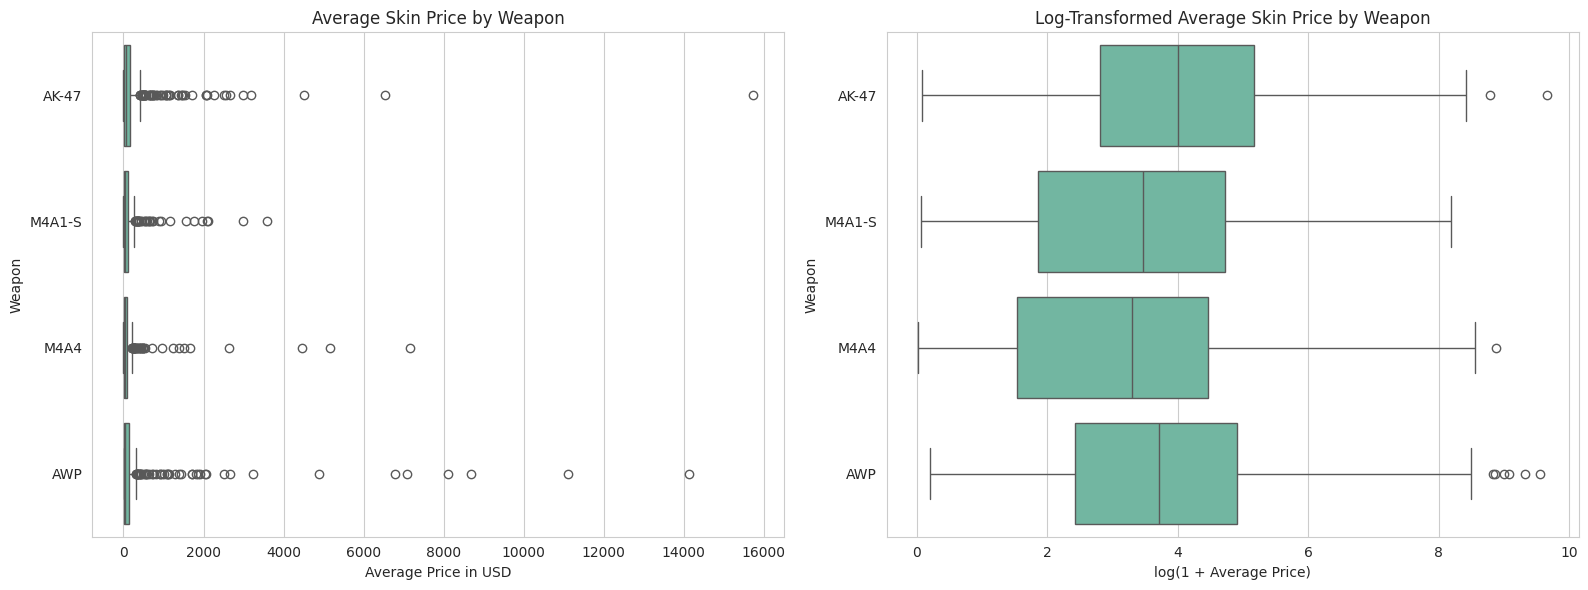

In [6]:
# Side-by-side box plots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Raw average price
sns.boxplot(
    data=df_weapons,
    x="avg",
    y="weapon",
    order=weapon_order,
    ax=axes[0]
)

axes[0].set_title("Average Skin Price by Weapon")
axes[0].set_xlabel("Average Price in USD")
axes[0].set_ylabel("Weapon")

# Log-transformed average price
sns.boxplot(
    data=df_weapons,
    x="log_avg",
    y="weapon",
    order=weapon_order,
    ax=axes[1]
)

axes[1].set_title("Log-Transformed Average Skin Price by Weapon")
axes[1].set_xlabel("log(1 + Average Price)")
axes[1].set_ylabel("Weapon")

plt.tight_layout()
plt.show()


With the boxplots, we are able to visualize the weapon skin outliers. Here we can see that the AWP has the most average price outliers. The maximum value out of all the weapons seems to be for the AK-47. However, since Skinport is a community based market, it could just be a seller over-valuing their item.

### Summary statistics

In [7]:
# quick overview of numeric variables

df[['min', 'max', 'avg', 'median', 'volume']].describe().round(2)

,min,max,avg,median,volume
count,1445.00,1445.00,1445.00,1445.00,1445.00
mean,206.92,272.99,228.27,225.25,40.81
std,868.98,932.84,895.29,894.40,72.11
min,0.02,0.03,0.02,0.02,1.00
25%,5.86,13.92,8.19,7.79,4.00
50%,29.78,56.11,37.49,35.93,13.00
75%,102.64,181.07,126.03,119.76,44.00
max,15726.81,15726.81,15726.81,15726.81,768.00


### Average price by condition

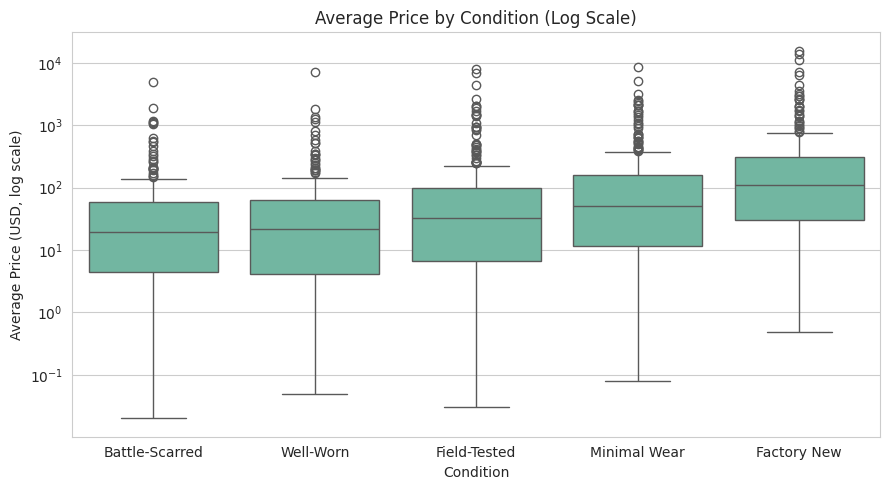

In [8]:
condition_labels = {
    0: 'Battle-Scarred', 
    1: 'Well-Worn', 
    2: 'Field-Tested', 
    3: 'Minimal Wear', 
    4: 'Factory New'
}

df['condition_label'] = df['condition'].map(condition_labels)
df = df.dropna(subset=['condition_label'])
cond_order = ['Battle-Scarred', 'Well-Worn', 'Field-Tested', 'Minimal Wear', 'Factory New']

fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=df, x='condition_label', y='avg', order=cond_order, ax=ax)
ax.set_yscale('log')
ax.set_title('Average Price by Condition (Log Scale)')
ax.set_xlabel('Condition')
ax.set_ylabel('Average Price (USD, log scale)')
plt.tight_layout()
plt.show()

### Price premium: StatTrak and Souvenir

StatTrak skins track kill counts and typically sell at a premium. Souvenir skins are tournament drops and tend to have different pricing dynamics. We compare median average prices across these categories.

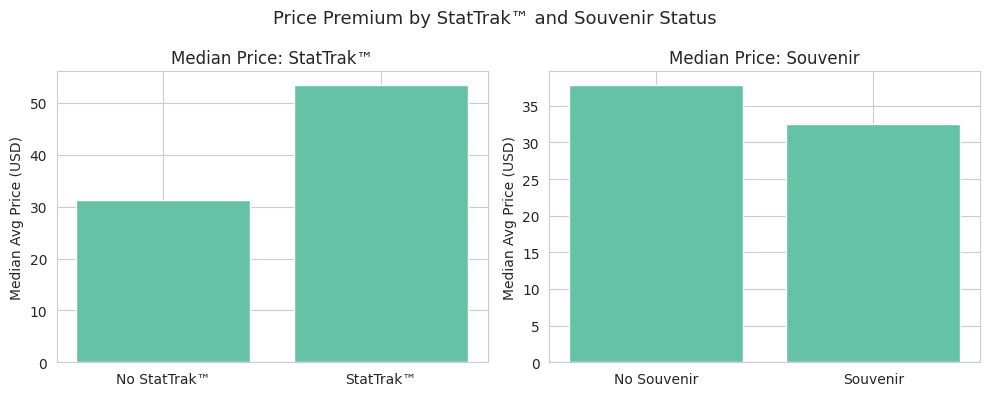

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, col, label in zip(axes, ['stat_trak', 'souvenir'], ['StatTrak™', 'Souvenir']):
    medians = df.groupby(col)['avg'].median()
    ax.bar([f'No {label}', label], [medians.get(0, 0), medians.get(1, 0)])
    ax.set_title(f'Median Price: {label}')
    ax.set_ylabel('Median Avg Price (USD)')

plt.suptitle('Price Premium by StatTrak™ and Souvenir Status', fontsize=13)
plt.tight_layout()
plt.show()

### Sales volume by weapon

Sales volume reflects market liquidity. Higher volume indicates more actively traded skins.

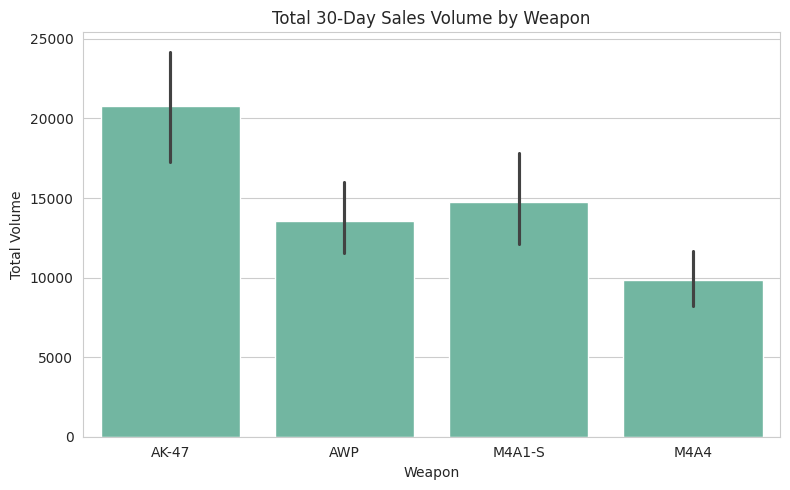

In [10]:
weapon_order = df.groupby('weapon')['avg'].median().sort_values(ascending=False).index
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=df, x='weapon', y='volume', order=weapon_order,
            estimator='sum', ax=ax)
ax.set_title('Total 30-Day Sales Volume by Weapon')
ax.set_xlabel('Weapon')
ax.set_ylabel('Total Volume')
plt.tight_layout()
plt.show()

### Correlation heatmap

We examine pairwise correlations among the numeric variables. Strong correlation between `min`, `max`, `avg`, and `median` is expected since they all summarize the same prices. The relationship between `condition` and price is what we mainly care about.

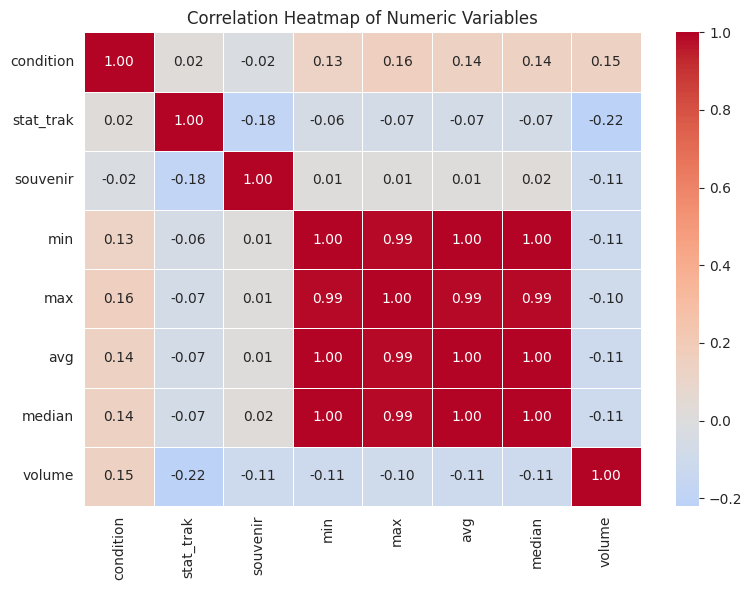

In [11]:
numeric_cols = ['condition', 'stat_trak', 'souvenir', 'min', 'max', 'avg', 'median', 'volume']
corr = df[numeric_cols].corr().round(2)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, ax=ax)
ax.set_title('Correlation Heatmap of Numeric Variables')
plt.tight_layout()
plt.show()

### Top 10 most expensive skins

We identify the ten skins with the highest median average price over the past 30 days.

In [12]:
top10 = (
    df.groupby(['weapon', 'skin_name'])['avg']
    .median()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)
top10.columns = ['Weapon', 'Skin', 'Median Avg Price (USD)']
top10['Median Avg Price (USD)'] = top10['Median Avg Price (USD)'].round(2)
top10

,Weapon,Skin,Median Avg Price (USD)
0,AK-47,Wild Lotus,15726.81
1,AWP,Gungnir,8099.76
2,AWP,Dragon Lore,7729.65
3,M4A4,Howl,5172.45
4,M4A1-S,Knight,2984.14
5,AWP,The Prince,2627.38
6,AK-47,Hydroponic,2083.46
7,M4A1-S,Hot Rod,2026.25
8,AWP,Medusa,1885.20
9,M4A1-S,Imminent Danger,1767.19


---
# 4. Results

We now implement the methodology from Section 2. We start with a naive baseline on raw prices, fix its problems with the log transform, compare OLS specifications, and then bring in the Lasso, first on raw prices and then in our final model with the full skin level feature set. We reload the cleaned data and set up the log transformed variables first.

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
import statsmodels.api as sm
import scipy.stats as stats

sns.set_style('whitegrid')
sns.set_palette('Set2')

# Load cleaned data
df = pd.read_csv('data/skinport_items_cleaned(1).csv')
df = df.drop(columns=['version', 'currency'], errors='ignore')

# Filter to the 4 weapons used in analysis
weapon_order = ['AK-47', 'M4A1-S', 'M4A4', 'AWP']
df_weapons = df[df['weapon'].isin(weapon_order)].copy()
df_weapons['avg'] = pd.to_numeric(df_weapons['avg'], errors='coerce')
df_weapons = df_weapons.dropna(subset=['avg'])

# Log-transform skewed variables
df_weapons['log_avg']    = np.log(df_weapons['avg'])
df_weapons['log_volume'] = np.log(df_weapons['volume'])

## 4.1 Baseline: MLR on raw prices

Before anything fancier, we establish a baseline. Using `statsmodels`, we fit an unpenalized multiple linear regression predicting the raw average price from `condition`, `souvenir`, and `stat_trak`. The summary will give us a baseline R-squared and p-values, setting a floor for predictive performance and exposing any immediate structural problems in the data.

In [14]:
import statsmodels.formula.api as smf

# Rename column 'avg' to avoid any python keyword conflicts if needed
# and clean up column names if they have trailing whitespaces
df.columns = [c.strip() for c in df.columns]

# Fit the Multiple Linear Regression model
# 'C(condition)' treats condition as a categorical factor variable 
# instead of a continuous variable, which it might want to due to the int type
mlr_formula = "avg ~ C(condition) + souvenir + stat_trak"
mlr_model = smf.ols(formula=mlr_formula, data=df).fit()

# print model summary
print(mlr_model.summary())

                            OLS Regression Results                            
Dep. Variable:                    avg   R-squared:                       0.029
Model:                            OLS   Adj. R-squared:                  0.025
Method:                 Least Squares   F-statistic:                     7.224
Date:                Wed, 10 Jun 2026   Prob (F-statistic):           1.30e-07
Time:                        19:47:30   Log-Likelihood:                -11850.
No. Observations:                1445   AIC:                         2.371e+04
Df Residuals:                    1438   BIC:                         2.375e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept           132.8865     59.39

The summary reveals a very poor fit, with an R-squared near zero (about 0.029, so the model accounts for only 2.9% of the variance). To see exactly why the linear fit is failing, we plot predicted versus actual prices. The scatter plot shows how vulnerable an unpenalized OLS model on raw prices is to the huge luxury skin outliers, and how little validity the model has without better handling of the skew.

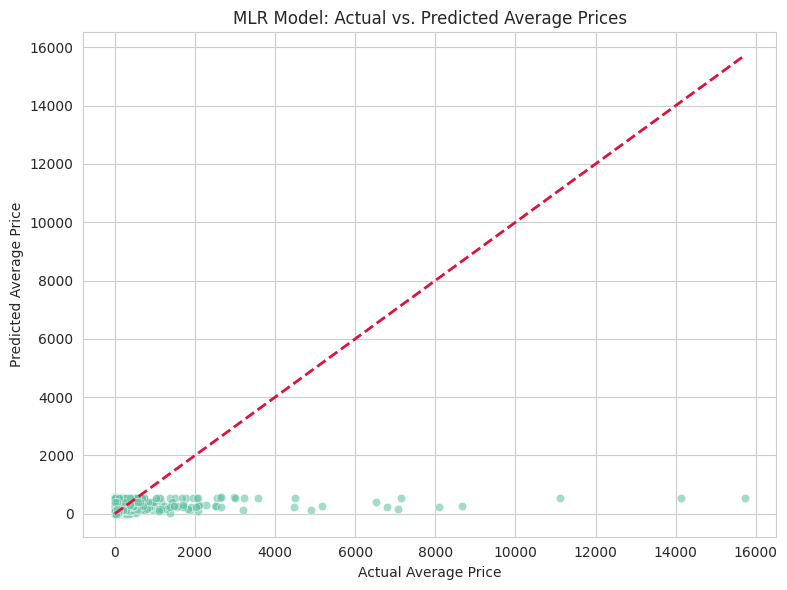

In [15]:
# Generate predictions
df['predicted_avg'] = mlr_model.predict(df)

# Plot actual vs predicted values
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='avg', y='predicted_avg', alpha=0.6)

# Plot a 45-degree line representing perfect prediction
max_val = max(df['avg'].max(), df['predicted_avg'].max())
min_val = min(df['avg'].min(), df['predicted_avg'].min())
plt.plot([min_val, max_val], [min_val, max_val], color='crimson', lw=2, linestyle='--')

plt.title('MLR Model: Actual vs. Predicted Average Prices')
plt.xlabel('Actual Average Price')
plt.ylabel('Predicted Average Price')
plt.tight_layout()
plt.show()

---
## 4.2 Modeling log price

As laid out in Section 2.1, we now apply a log transformation to `avg` to stabilize the variance and get closer to satisfying MLR's homoscedasticity assumption. Similarly, `volume` is log transformed since sales activity follows a multiplicative pattern.

Our best OLS specification is:

$$\log(\text{avg\_price}) = \beta_0 + \beta_1\,\text{condition} + \beta_2\,\text{souvenir} + \beta_3\,\mathbf{1}_{\text{AWP}} + \beta_4\,\mathbf{1}_{\text{M4A1-S}} + \beta_5\,\mathbf{1}_{\text{M4A4}} + \beta_6\,\log(\text{volume}) + \varepsilon$$

*(AK-47 is the reference weapon category)*

### Model comparison

We fit three nested models of increasing complexity and compare them using adjusted R-squared, AIC, and BIC (Section 2.2). Lower AIC/BIC indicates a better balance of fit versus complexity. M2 adds the StatTrak and Souvenir flags, which help only a little on their own. M3 adds weapon category and log volume, which matter much more; we drop `stat_trak` there to keep the benchmark lean, and let the regularized models in the next sections decide for themselves whether to keep it.

In [16]:
m1 = smf.ols('log_avg ~ condition',                                          data=df_weapons).fit()
m2 = smf.ols('log_avg ~ condition + souvenir + stat_trak',                   data=df_weapons).fit()
m3 = smf.ols('log_avg ~ condition + souvenir + C(weapon) + log_volume',      data=df_weapons).fit()

rows = []
for name, m in [
    ('M1: condition only',                m1),
    ('M2: + souvenir + stat_trak',        m2),
    ('M3: + weapon + log_volume (best OLS)', m3),
]:
    rows.append({
        'Model':    name,
        'k':        int(m.df_model) + 2,
        'R²':       round(m.rsquared, 4),
        'Adj. R²':  round(m.rsquared_adj, 4),
        'AIC':      round(m.aic, 1),
        'BIC':      round(m.bic, 1),
    })

pd.DataFrame(rows)


,Model,k,R²,Adj. R²,AIC,BIC
0,M1: condition only,3,0.0873,0.0867,6284.4,6295.0
1,M2: + souvenir + stat_trak,5,0.1032,0.1014,6263.1,6284.2
2,M3: + weapon + log_volume (best OLS),8,0.3110,0.3081,5888.2,5925.1


### Best OLS model summary

M3 achieves the lowest AIC and BIC and the highest adjusted R-squared among the OLS specifications, so we use it as our best OLS benchmark before moving to regularized models.

In [17]:
print(m3.summary())


                            OLS Regression Results                            
Dep. Variable:                log_avg   R-squared:                       0.311
Model:                            OLS   Adj. R-squared:                  0.308
Method:                 Least Squares   F-statistic:                     108.2
Date:                Wed, 10 Jun 2026   Prob (F-statistic):          1.20e-112
Time:                        19:47:31   Log-Likelihood:                -2937.1
No. Observations:                1445   AIC:                             5888.
Df Residuals:                    1438   BIC:                             5925.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept               4.1968    

### Coefficient interpretation

Because the response is log-transformed, coefficients are interpreted on a **multiplicative scale**: a coefficient $\hat{\beta}$ means the predicted price is multiplied by $e^{\hat{\beta}}$ for a one-unit increase in that predictor, holding all others constant.

| Predictor | Coef | Multiplier | Interpretation |
|---|---|---|---|
| Condition (+1 tier) | +0.661 | ×1.94 | Each wear tier roughly doubles the price |
| Souvenir | −0.393 | ×0.68 | Souvenir skins are ~32% cheaper on average |
| AWP vs AK-47 | −0.210 | ×0.81 | AWP skins slightly cheaper than AK-47 |
| M4A1-S vs AK-47 | −0.692 | ×0.50 | M4A1-S skins ~50% cheaper than AK-47 |
| M4A4 vs AK-47 | −1.372 | ×0.25 | M4A4 skins ~75% cheaper than AK-47 |
| Volume (doubling) | −0.633 | ×0.64 | Skins that trade twice as often sell ~36% cheaper |

*(For volume the multiplier is the effect of doubling, $e^{\hat{\beta}\ln 2}$, since the predictor is log volume.)*

### Diagnostic plots

We verify the four standard MLR assumptions:
1. **Residuals vs. Fitted**: linearity and homoscedasticity
2. **Normal Q-Q**: normality of residuals
3. **Scale-Location**: constant residual spread
4. **Residuals vs. Leverage**: influential observations

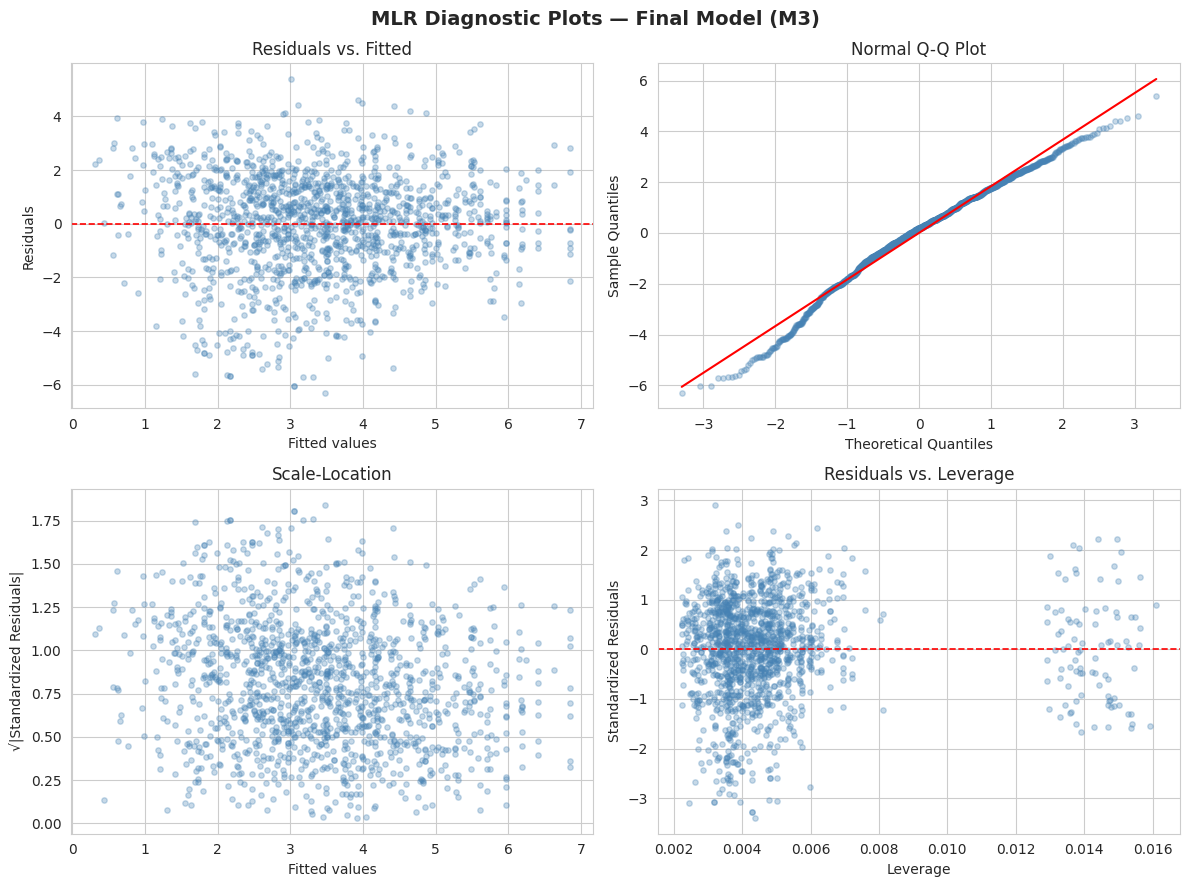

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
fig.suptitle('MLR Diagnostic Plots — Final Model (M3)', fontsize=14, fontweight='bold')

fitted    = m3.fittedvalues
resid     = m3.resid
std_resid = resid / resid.std()

# 1. Residuals vs Fitted
ax = axes[0, 0]
ax.scatter(fitted, resid, alpha=0.3, s=15, color='steelblue')
ax.axhline(0, color='red', linewidth=1.2, linestyle='--')
ax.set_xlabel('Fitted values'); ax.set_ylabel('Residuals')
ax.set_title('Residuals vs. Fitted')

# 2. Q-Q Plot
ax = axes[0, 1]
(osm, osr), (slope, intercept, _) = stats.probplot(resid, dist='norm')
ax.scatter(osm, osr, alpha=0.3, s=15, color='steelblue')
ax.plot(osm, slope * np.array(osm) + intercept, color='red', linewidth=1.5)
ax.set_xlabel('Theoretical Quantiles'); ax.set_ylabel('Sample Quantiles')
ax.set_title('Normal Q-Q Plot')

# 3. Scale-Location
ax = axes[1, 0]
ax.scatter(fitted, np.sqrt(np.abs(std_resid)), alpha=0.3, s=15, color='steelblue')
ax.set_xlabel('Fitted values'); ax.set_ylabel('√|Standardized Residuals|')
ax.set_title('Scale-Location')

# 4. Residuals vs Leverage
leverage = m3.get_influence().hat_matrix_diag
ax = axes[1, 1]
ax.scatter(leverage, std_resid, alpha=0.3, s=15, color='steelblue')
ax.axhline(0, color='red', linewidth=1.2, linestyle='--')
ax.set_xlabel('Leverage'); ax.set_ylabel('Standardized Residuals')
ax.set_title('Residuals vs. Leverage')

plt.tight_layout()
plt.show()


### Limitations of the OLS model

- **R-squared = 0.31.** Condition, weapon type, and volume explain about 31% of log-price variance. The remaining variance likely reflects skin rarity and visual desirability, which the attribute columns simply do not capture.
- The Q-Q plot shows mild heavy tails, meaning the residuals are slightly non-normal. A small number of ultra-rare skins (e.g. the AK-47 Fire Serpent) produce large outliers the model cannot fully account for.
- **Souvenir** (p = 0.056) is borderline significant and may not hold in every subsample.

---
## 4.3 Lasso on raw prices

The log model fixed the distribution problems but stalls around an R-squared of 0.31, since it has no idea which skin each row actually is. Before adding skin identity, we wanted to see how far regularization alone could get on the raw prices.

We expand the feature matrix to include `weapon` and `volume`. Adding more dimensions risks overfitting a standard OLS fit, which is where Lasso regression comes in. As described in Section 2.4, the L1 penalty shrinks the coefficients of irrelevant features exactly to zero, so the model stays sparse and driven by real pricing signals. We dummy encode the categoricals and do a standard 75/25 train test split to measure out of sample performance.

In [19]:
from sklearn.model_selection import train_test_split

# Drop columns that have direct data leakage with average price (min, max, median) as we only care about average
# include weapon and volume to let Lasso perform selection
X = pd.get_dummies(df[['weapon', 'condition', 'volume', 'souvenir', 'stat_trak']], 
                   columns=['weapon', 'condition'], drop_first=True)
y = df['avg']

# Split the data into 75% training and 25% testing, as is standard
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

print(f"Training set: {X_train.shape[0]} observations")
print(f"Test set: {X_test.shape[0]} observations")

Training set: 1083 observations
Test set: 362 observations


Penalized regression applies a shrinkage penalty based on coefficient size. Because our features live on very different scales (continuous volume versus binary dummies), we standardize the training data to mean zero and unit variance so the L1 penalty treats every predictor fairly. The scaler is fit on the training set only (Section 2.3).

In [20]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

With the data scaled, we test three configurations: an unpenalized OLS baseline, a fixed Lasso model with $\alpha = 1$, and a cross-validated Lasso (`LassoCV`) that searches a logarithmic grid for the best penalty. This lets us watch how deliberately introducing a little bias through the L1 constraint helps manage variance.

In [21]:
from sklearn.linear_model import LinearRegression, Lasso, LassoCV
from sklearn.metrics import mean_squared_error

# 1. OLS baseline
ols_model = LinearRegression().fit(X_train_scaled, y_train)

# 2. fixed lasso where alpha = 1
lasso_fixed = Lasso(alpha=1, max_iter=10000, random_state=42)
lasso_fixed.fit(X_train_scaled, y_train)

# 3. CV Tuned Lasso (Searching over an alpha grid using 10-fold CV)
lasso_cv = LassoCV(alphas=np.logspace(-3, 3, 100), cv=10, max_iter=10000, random_state=42)
lasso_cv.fit(X_train_scaled, y_train)

print(f"Lasso optimal λ (alpha) selected via CV: {lasso_cv.alpha_:.4f}")

Lasso optimal λ (alpha) selected via CV: 2.1544


Having fit all three models, we compare their out-of-sample mean squared error and the number of retained features. We expect the CV-tuned Lasso to have the lowest test error while shrinking some irrelevant coefficients to zero.

In [22]:
results = []
for name, mdl in [('OLS Baseline', ols_model),
                  ('Lasso (alpha=1)', lasso_fixed),
                  ('Lasso (CV-Tuned)', lasso_cv)]:
    y_pred = mdl.predict(X_test_scaled)
    results.append({
        'Model': name,
        'Test MSE': round(mean_squared_error(y_test, y_pred), 1),
        'Features Retained': int((mdl.coef_ != 0).sum()),
    })

pd.DataFrame(results)

,Model,Test MSE,Features Retained
0,OLS Baseline,240020.2,10
1,Lasso (alpha=1),239270.8,10
2,Lasso (CV-Tuned),238489.4,9


The comparison confirms the CV-tuned Lasso dropped one variable and slightly improved the test error. To see how this variable selection happens, we trace the coefficient path across a range of $\lambda$ values. The plot shows the L1 constraint forcing coefficients to the zero axis as the penalty grows, with our cross-validated $\lambda$ marked.

Still, the MSE is very high in absolute terms because of the right-skewed outliers. This motivates our final model.

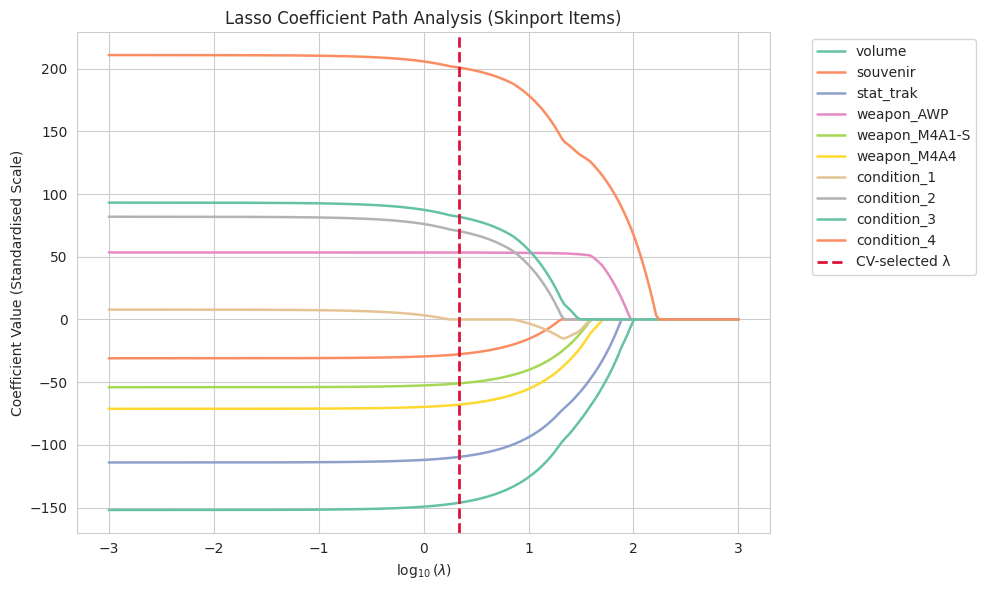

In [23]:
alphas = np.logspace(-3, 3, 200)
coef_paths = np.array([Lasso(alpha=a, max_iter=10000, random_state=42).fit(X_train_scaled, y_train).coef_ for a in alphas])

plt.figure(figsize=(10, 6))
for j, feature_name in enumerate(X.columns):
    plt.plot(np.log10(alphas), coef_paths[:, j], label=feature_name, lw=1.8)

plt.axvline(np.log10(lasso_cv.alpha_), color='crimson', linestyle='--', lw=2, label='CV-selected λ')
plt.title('Lasso Coefficient Path Analysis (Skinport Items)')
plt.xlabel(r'$\log_{10}(\lambda)$')
plt.ylabel('Coefficient Value (Standardised Scale)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

---
## 4.4 Final model: log price plus skin identity

While the regularized model reduced variance a bit, the absolute error stays high because of the extreme right-tail outliers. To fix this we build the V2 model, combining the two lessons so far.

First, we log transform the target (`avg`) to compress the tail, shifting predictions from additive dollar amounts to multiplicative percentage changes, exactly like in Section 4.2. Second, we expand the feature space to include the specific `skin_name`. This removes the omitted variable problem that held back our earlier models, since the EDA and the OLS limitations both pointed at skin identity as the missing ingredient.

This is where the Lasso model is going to excel. There are around 200 individual skin names with only about 4 observations per skin on average, so plain OLS coefficients on the skin dummies would be very unstable. The L1 penalty keeps the high-dimensional fit under control and zeroes out the skins that carry no real signal.

In [24]:
# 1. log transform the dependent variable
# We use log1p (log(1 + x)) to safely handle any values very close to 0
y_log = np.log1p(df['avg'])

# 2. 3xpand the Feature Space to include the actual skin finishes, which we couldn't have before
X_expanded = pd.get_dummies(df[['weapon', 'skin_name', 'condition', 'volume', 'souvenir', 'stat_trak']], 
                            columns=['weapon', 'skin_name', 'condition'], drop_first=True)

# 3. train / test split using the new matrices
X_train_exp, X_test_exp, y_train_log, y_test_log = train_test_split(X_expanded, y_log, test_size=0.25, random_state=42)

# 4.standardize the expanded feature set
scaler_exp = StandardScaler()
X_train_exp_scaled = scaler_exp.fit_transform(X_train_exp)
X_test_exp_scaled = scaler_exp.transform(X_test_exp)

# 5. fit the new CV-Tuned Lasso Model
# we increase max_iter because the expanded feature space takes longer to converge
lasso_cv_v2 = LassoCV(alphas=np.logspace(-4, 1, 100), cv=10, max_iter=50000, random_state=42)
lasso_cv_v2.fit(X_train_exp_scaled, y_train_log)

# 6. Evaluate Performance on the original dollar scale
# We must use expm1 (exponential minus 1) to reverse the log1p transform for our predictions
y_pred_log = lasso_cv_v2.predict(X_test_exp_scaled)
y_pred_dollars = np.expm1(y_pred_log)
y_test_dollars = np.expm1(y_test_log)

v2_mse = mean_squared_error(y_test_dollars, y_pred_dollars)
n_features_v2 = (lasso_cv_v2.coef_ != 0).sum()

print(f"V2 Lasso optimal λ: {lasso_cv_v2.alpha_:.5f}")
print(f"V2 Test MSE (in dollars squared): {v2_mse:.2f}")
print(f"V2 Test RMSE (in dollars): ${np.sqrt(v2_mse):.2f}")
print(f"Features Retained: {n_features_v2} / {X_expanded.shape[1]}")

V2 Lasso optimal λ: 0.00413
V2 Test MSE (in dollars squared): 48092.16
V2 Test RMSE (in dollars): $219.30
Features Retained: 193 / 201


The V2 model is a big improvement, dropping the RMSE to around 220 dollars while keeping the vast majority of the skin-specific features.

Because we predicted the log of the price, the coefficients act as multiplicative scaling factors. Here we extract the non-zero coefficients and convert them into percentage markups, which lets us see exactly which skins and conditions carry the biggest market premiums.

In [25]:
# Features and their coefficients, keeping only what Lasso kept
coef_df = pd.DataFrame({
    'Feature': X_expanded.columns,
    'Log_Coefficient': lasso_cv_v2.coef_
})
coef_df = coef_df[coef_df['Log_Coefficient'] != 0]

# Convert log coefficients into percentage markups: (e^beta - 1) * 100
coef_df['Percentage_Markup'] = (np.exp(coef_df['Log_Coefficient']) - 1) * 100

coef_df_sorted = coef_df.sort_values(by='Log_Coefficient', ascending=False).round(3)

# Top 10 value-adding features
coef_df_sorted.head(10).reset_index(drop=True)

,Feature,Log_Coefficient,Percentage_Markup
0,condition_4,0.616,85.136
1,skin_name_Case Hardened,0.408,50.354
2,skin_name_Dragon Lore,0.339,40.315
3,skin_name_Desert Hydra,0.313,36.768
4,skin_name_Fire Serpent,0.310,36.401
5,skin_name_Gungnir,0.305,35.715
6,condition_3,0.304,35.537
7,skin_name_Medusa,0.245,27.776
8,skin_name_Printstream,0.236,26.612
9,skin_name_Asiimov,0.231,25.941


And the five features that drag price down the most:

In [26]:
# Bottom 5 value-decreasing features
coef_df_sorted.tail(5).reset_index(drop=True)

,Feature,Log_Coefficient,Percentage_Markup
0,skin_name_Mud-Spec,-0.210,-18.966
1,skin_name_Choppa,-0.229,-20.436
2,skin_name_Poly Mag,-0.229,-20.488
3,skin_name_Mainframe,-0.234,-20.901
4,skin_name_Wash me plz,-0.236,-21.024


The coefficients pick out the famously expensive skins (like the Dragon Lore and Case Hardened) as the biggest positive effects, and show that Factory New condition acts as a scaling markup: holding everything else constant, a Factory New skin carries an estimated 85% premium over a Battle-Scarred one.

To confirm the V2 model is behaving well, we plot predicted versus actual values on the log scale, alongside a residuals plot. We are looking for a tight fit along the 45-degree line and a balanced residual cloud, which would mean we have successfully dealt with the skew.

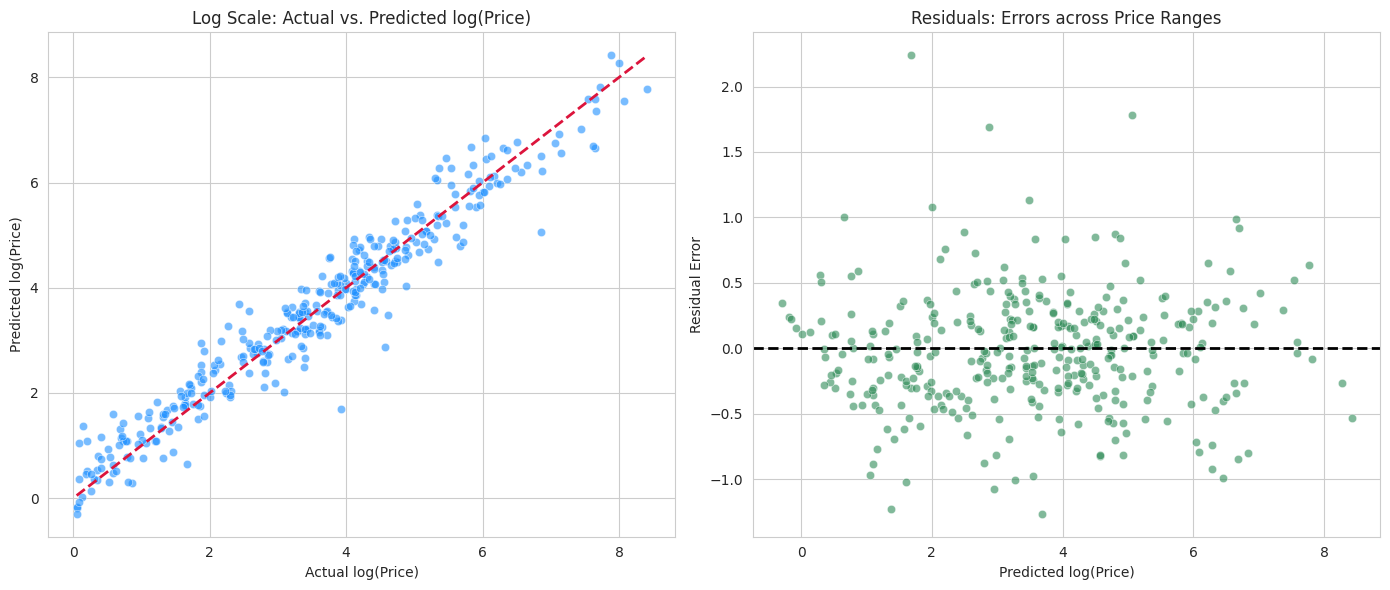

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Actual vs Predicted on Log Scale, which is how the model sees it
sns.scatterplot(x=y_test_log, y=y_pred_log, alpha=0.6, ax=axes[0], color='dodgerblue')
axes[0].plot([y_test_log.min(), y_test_log.max()], [y_test_log.min(), y_test_log.max()], 
             color='crimson', lw=2, linestyle='--')
axes[0].set_title('Log Scale: Actual vs. Predicted log(Price)')
axes[0].set_xlabel('Actual log(Price)')
axes[0].set_ylabel('Predicted log(Price)')

# Plot 2: Residuals Plot (Checking for bias, want a random scatter around 0 with no patterns)
residuals_log = y_test_log - y_pred_log
sns.scatterplot(x=y_pred_log, y=residuals_log, alpha=0.6, ax=axes[1], color='seagreen')
axes[1].axhline(0, color='black', lw=2, linestyle='--')
axes[1].set_title('Residuals: Errors across Price Ranges')
axes[1].set_xlabel('Predicted log(Price)')
axes[1].set_ylabel('Residual Error')

plt.tight_layout()
plt.show()

---
## 4.5 Using the model to look for mispriced skins

The diagnostic plots show a healthy, proportional fit across the whole price range.

As a final step, we try using the model to spot mispriced skins. We generate predictions for the entire dataset and compute the spread between the model's predicted price and the actual 30-day average. Sorting these spreads gives us the skins the model thinks are most undervalued (candidates to buy) and most overvalued (candidates to avoid or sell). We restrict to items that actually trade, so a thin market does not produce fake signals.

In [28]:
# Predictions for the full dataset using the V2 model
X_full_exp_scaled = scaler_exp.transform(X_expanded)
full_predictions_log = lasso_cv_v2.predict(X_full_exp_scaled)

# Reverse the log transform and add to the main dataframe
df['predicted_avg'] = np.expm1(full_predictions_log)

# Arbitrage spread: positive = model price above market price (possibly undervalued)
df['arbitrage_spread'] = df['predicted_avg'] - df['avg']
df['spread_percentage'] = (df['arbitrage_spread'] / df['avg']) * 100

# Filter for liquidity: only items that traded at least 10 times in the window
liquid_df = df[df['volume'] >= 10].copy()

cols_to_show = ['weapon', 'skin_name', 'condition', 'avg', 'predicted_avg',
                'arbitrage_spread', 'spread_percentage']

# Top 10 most undervalued skins (model price above market price)
undervalued_picks = liquid_df.sort_values(by='arbitrage_spread', ascending=False)
undervalued_picks[cols_to_show].head(10).round(2).reset_index(drop=True)

,weapon,skin_name,condition,avg,predicted_avg,arbitrage_spread,spread_percentage
0,AK-47,Case Hardened,3,340.70,796.04,455.34,133.65
1,M4A4,X-Ray,4,210.72,533.94,323.22,153.39
2,AK-47,Case Hardened,2,253.60,534.16,280.56,110.63
3,M4A1-S,Fade,4,376.10,637.13,261.03,69.40
4,M4A1-S,Cyrex,4,198.89,440.42,241.53,121.44
5,AK-47,Bloodsport,4,423.79,635.16,211.37,49.87
6,M4A1-S,Icarus Fell,4,657.58,863.37,205.79,31.30
7,AK-47,Vulcan,4,668.73,870.27,201.54,30.14
8,AK-47,Bloodsport,4,201.02,401.14,200.12,99.55
9,AK-47,Case Hardened,1,227.88,418.91,191.03,83.83


And the skins the model considers most overvalued:

In [29]:
# Top 10 most overvalued skins (market price above model price)
overvalued_picks = liquid_df.sort_values(by='arbitrage_spread', ascending=True)
overvalued_picks[cols_to_show].head(10).round(2).reset_index(drop=True)

,weapon,skin_name,condition,avg,predicted_avg,arbitrage_spread,spread_percentage
0,AWP,Desert Hydra,2,1387.05,909.68,-477.37,-34.42
1,M4A1-S,Hot Rod,4,1963.33,1713.67,-249.66,-12.72
2,M4A1-S,Printstream,3,567.38,352.46,-214.92,-37.88
3,AWP,Fade,4,1078.53,873.05,-205.48,-19.05
4,M4A4,Buzz Kill,3,344.31,173.32,-170.99,-49.66
5,AWP,Asiimov,0,290.17,120.22,-169.95,-58.57
6,M4A1-S,Nightmare,4,249.75,89.45,-160.30,-64.18
7,AWP,Desert Hydra,2,1439.24,1283.18,-156.06,-10.84
8,M4A4,Buzz Kill,2,258.44,110.46,-147.98,-57.26
9,M4A1-S,Printstream,2,373.90,228.40,-145.50,-38.92


As a quick sanity check, take one of the flagged candidates: the `M4A1-S Printstream` (StatTrak version) with condition = 2, which is Field-Tested on the Counter-Strike market. Our model says it is about 39% overvalued, with a predicted average price around \$228 against an actual 30-day average around \$373. Since our data snapshot is about a week old, looking at the current market should tell us whether the price has moved. Checking Skinport, we found the following Printstream listing:

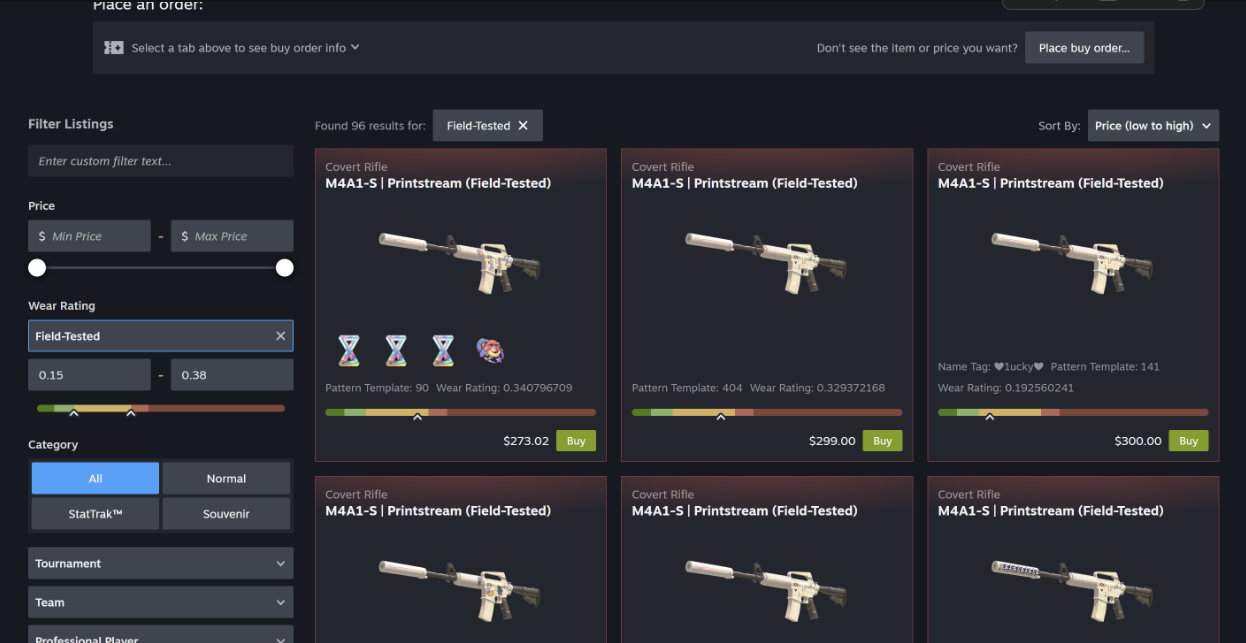

In about a week, the average dropped from around \$373 into the high 300s, moving toward the model's prediction. One example is obviously not proof that the strategy works, but it is encouraging that the model flagged a skin whose price did in fact fall.

---
# 5. Conclusion

We set out to figure out what drives CS2 skin prices on Skinport, and the modeling gives a pretty clear answer.

**Findings.** Raw prices are so skewed that a plain MLR on them is basically useless (R-squared around 0.03). On the log scale, the measurable attributes do carry real signal: each wear tier roughly doubles a skin's price, Souvenir status comes with a discount, and weapon category matters, with M4A4 skins selling for about a quarter of comparable AK-47 skins. But attributes alone top out around 31% of the variance in log price. The missing ingredient is the skin itself. Once we add roughly 200 skin name dummies through a CV-tuned Lasso, the model predicts held out prices with an RMSE around \$220, and the biggest coefficients are exactly the skins the community treats as grails (Dragon Lore, Case Hardened, Fire Serpent). The Lasso kept most of the skin dummies, which tells us the skin effects are mostly genuine signal rather than noise.

**Conclusions.** For our research questions: condition, StatTrak, Souvenir, and weapon all relate to price in interpretable ways, but they are second order compared to skin identity. A skin's price is mostly about which skin it is, and the attributes scale that base value up or down. The model is also accurate enough to be useful: ranking residuals surfaced plausible mispricings, and our one spot check (the M4A1-S Printstream) moved toward the model's prediction within a week. We would not bet money on a single backtest-free example, but it suggests the approach has something to it.

**Further work.** There are a few natural continuations we did not have time for:

- **More weapons.** We only covered the four most popular guns. Extending to knives, gloves, and pistols would test whether the same attribute effects hold in those markets.
- **Repeated snapshots over time.** Our data is one 30-day window. Pulling the API weekly would turn this into a time series problem and let us actually backtest the mispricing strategy instead of spot checking one skin.
- **Richer features.** Pattern indexes, float values, and sticker placements are known to matter for collectors but are not in the Skinport aggregates.
- **More flexible models.** With a much larger sample, tree ensembles or neural networks could pick up non-linear effects. At 1,445 rows they would mostly just overfit, which is why we stuck with regularized linear models.

---
# 6. References

1. Skinport. *Skinport API Documentation.* https://docs.skinport.com (sales history endpoint: `https://api.skinport.com/v1/sales/history`)
2. Inston, J. (2026). *PSTAT 100: Data Science Concepts and Analysis, Lecture Notes.* University of California, Santa Barbara. (Lectures 14 and 15: model selection and regularization.)
3. Valve Corporation. (2023). *Counter-Strike 2.* https://www.counter-strike.net
